In [57]:
#librerias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

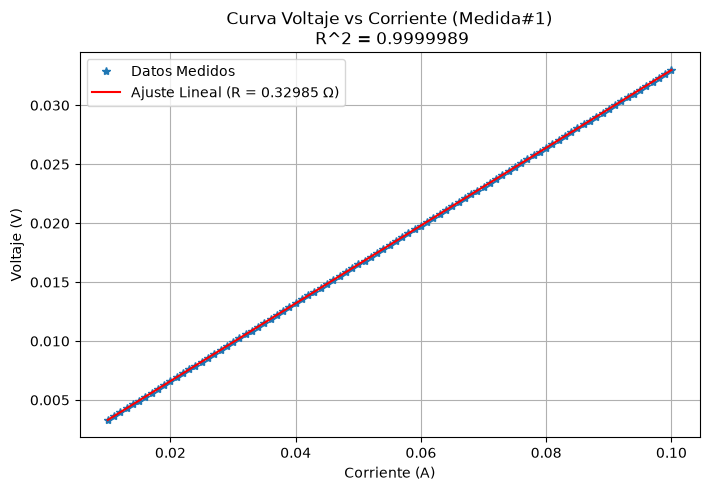

In [94]:
# Leer los datos y extraer unicamente los datos de interes 
df1 = pd.read_csv('medi1.csv', skiprows=8)
voltage_12 = df1['Reading'].astype(float)
current_43 = df1['Value'].astype(float)

# Calcular resistencia por pendiente (Ajuste lineal V = R*I + offset)
R_slope1, offset1 = np.polyfit(current_43, voltage_12, 1)
r_squared1 = np.corrcoef(current_43, voltage_12)[0, 1]**2
# Graficar la curva V vs I
plt.figure(figsize=(8, 5))
plt.plot(current_43, voltage_12, '*', label='Datos Medidos')
plt.plot(current_43, R_slope1 * current_43 + offset1, 'r-', label=f'Ajuste Lineal (R = {R_slope1:.5f} Ω)')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title(f'Curva Voltaje vs Corriente (Medida#1)\n R^2 = {r_squared1:.7f}')
plt.grid(True)
plt.legend()
plt.savefig("Medida1")
plt.show()


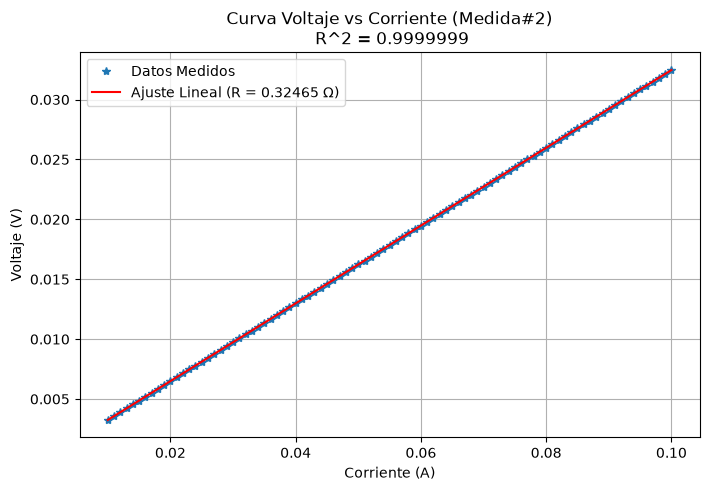

In [95]:
# Leer los datos y extraer unicamente los datos de interes 
df2 = pd.read_csv('medi2.csv', skiprows=8)
voltage_43 = df2['Reading'].astype(float)
current_12 = df2['Value'].astype(float)

# Calcular resistencia por pendiente (Ajuste lineal V = R*I + offset)
R_slope2, offset2 = np.polyfit(current_12, voltage_43, 1)
r_squared2 = np.corrcoef(current_12, voltage_43)[0, 1]**2

# Graficar la curva V vs I
plt.figure(figsize=(8, 5))
plt.plot(current_12, voltage_43, '*', label='Datos Medidos')
plt.plot(current_12, R_slope2 * current_12 + offset2, 'r-', label=f'Ajuste Lineal (R = {R_slope2:.5f} Ω)')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title(f'Curva Voltaje vs Corriente (Medida#2)\n R^2 = {r_squared2:.7f}')
plt.grid(True)
plt.legend()
plt.savefig("Medida2")
plt.show()

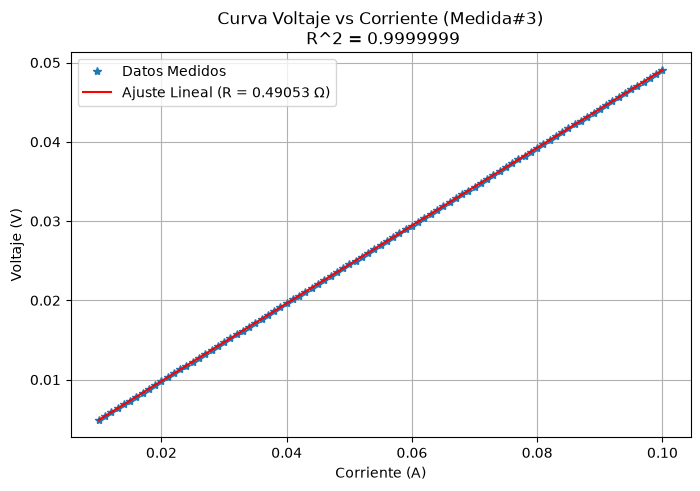

In [96]:
# Leer los datos y extraer unicamente los datos de interes 
df3 = pd.read_csv('medi3.csv', skiprows=8)
voltage_23 = df3['Reading'].astype(float)
current_14 = df3['Value'].astype(float)

# Calcular resistencia por pendiente (Ajuste lineal V = R*I + offset)
R_slope3, offset3 = np.polyfit(current_14, voltage_23, 1)
r_squared3 = np.corrcoef(current_14, voltage_23)[0, 1]**2

# Graficar la curva V vs I
plt.figure(figsize=(8, 5))
plt.plot(current_14, voltage_23, '*', label='Datos Medidos')
plt.plot(current_14, R_slope3 * current_14 + offset3, 'r-', label=f'Ajuste Lineal (R = {R_slope3:.5f} Ω)')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title(f'Curva Voltaje vs Corriente (Medida#3)\n R^2 = {r_squared3:.7f}')
plt.grid(True)
plt.legend()
plt.savefig("Medida3")
plt.show()

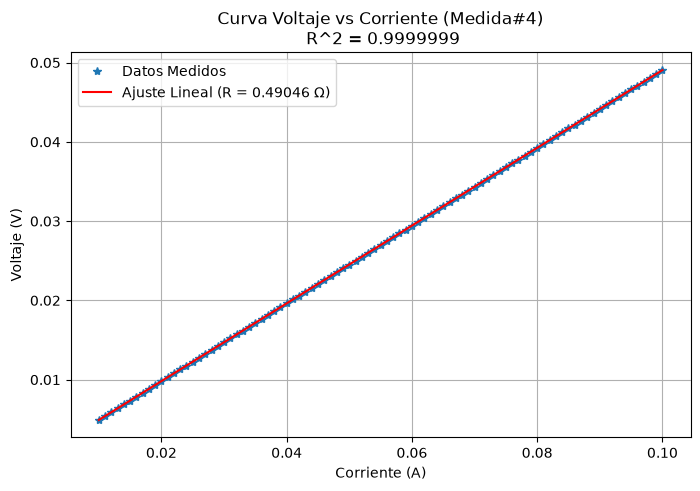

In [97]:
# Leer los datos y extraer unicamente los datos de interes 
df4 = pd.read_csv('medi4.csv', skiprows=8)
voltage_14 = df4['Reading'].astype(float)
current_23 = df4['Value'].astype(float)

# Calcular resistencia por pendiente (Ajuste lineal V = R*I + offset)
R_slope4, offset4 = np.polyfit(current_23, voltage_14, 1)
r_squared4 = np.corrcoef(current_23, voltage_14)[0, 1]**2

# Graficar la curva V vs I
plt.figure(figsize=(8, 5))
plt.plot(current_23, voltage_14, '*', label='Datos Medidos')
plt.plot(current_23, R_slope4 * current_23 + offset4, 'r-', label=f'Ajuste Lineal (R = {R_slope4:.5f} Ω)')
plt.xlabel('Corriente (A)')
plt.ylabel('Voltaje (V)')
plt.title(f'Curva Voltaje vs Corriente (Medida#4)\n R^2 = {r_squared4:.7f}')
plt.grid(True)
plt.legend()
plt.savefig("Medida4")
plt.show()

In [117]:
# Calcular R_{||} y R_{=}
R_a = (R_slope1 + R_slope2)/2 # R_{||}
R_b = (R_slope3 + R_slope4)/2 # R_{=}

print(f"R_∥: {R_a:.2f} Ω")
print(f"R_= : {R_b:.2f} Ω")

# Crear la ecuacion para realizar el despeje de R_s
def vanderpauw(R_s):
    return np.exp(-np.pi * R_a / R_s) + np.exp(-np.pi * R_b / R_s) - 1.0

# Encontrar el valor de R_s
r_init = 0.1 #Valor inicial para la busqueda de la solución 
R_s,  = fsolve(vanderpauw, x0=r_init) 
print(f"R_s : {R_s:.2f} Ω")

# Calculo del grosor de la pelicula 
resistividad = 1.68e-8

grosor = resistividad / R_s
grosor_nm = grosor * 1e9
print (f"El grosor de la pelicula delgada es de: {grosor_nm:.2f} nm")


R_∥: 0.33 Ω
R_= : 0.49 Ω
R_s : 1.83 Ω
El grosor de la pelicula delgada es de: 9.19 nm
